# Su-LSTM baseline — matched prefix-level comparison

This notebook rebuilds the supervised LSTM (Su-LSTM) baseline on the **current 981-scenario dataset** and matches the endpoint set and prefix-level split used in the uploaded GAT/CMPA notebooks.

### Preserved protocol
- five-dimensional input: `[d, theta, sin(yaw), cos(yaw), v]`;
- common endpoints: frame indices `3..14` = prefixes of length `4..15`;
- prefix-level 80/20 random split using `torch.manual_seed(42)`;
- asymmetric `P -> U` corruption only on training labels;
- validation data remain clean.

### Su-LSTM label semantics
Following the current manuscript description, the supervised baseline assigns the eventual scenario outcome

`Y_m = max_t s_t^m`

to every prefix from that scenario. Thus all prefixes from a collision scenario are supervised as positive.

For transparency, the notebook reports two evaluations:
1. **Primary current-risk evaluation:** against the clean endpoint label `s_t`, directly comparable to the GAT/CMPA/TF current-risk experiments.
2. **Legacy scenario-outcome evaluation:** against `Y_m`, reported separately and never mixed with current-risk F1.


In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score,
)

import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MIN_ENDPOINT = 3
MAX_ENDPOINT = 14

INPUT_DIM = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 8
EARLY_STOP_MIN_DELTA = 1e-3
THRESHOLD = 0.5

NOISE_CONDITIONS = [
    ("none", 0.00),
    ("p_to_u", 0.05),
    ("p_to_u", 0.10),
    ("p_to_u", 0.15),
    ("p_to_u", 0.20),
]

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Device:", DEVICE)


Device: cuda


In [2]:
# Load the current processed dataset.
DATASET_CANDIDATES = [
    Path("safe_col_mix.txt"),
]

TXT_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if TXT_PATH is None:
    raise FileNotFoundError("safe_col_mix.txt not found.")

def load_mix_txt(path):
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data[None, :]
    if data.shape[1] < 8:
        raise ValueError("Expected 8 columns.")
    return data

def group_sequences_with_frame_labels(data):
    seq_col = data[:, 7].astype(int)
    sequences, frame_labels, seq_ids = [], [], []
    for sid in np.unique(seq_col):
        seq_data = data[seq_col == sid]
        seq_data = seq_data[np.argsort(seq_data[:, 0])]
        sequences.append(seq_data[:, 1:6].astype(np.float32))
        frame_labels.append(seq_data[:, 6].astype(np.float32))
        seq_ids.append(int(sid))
    return sequences, frame_labels, seq_ids

raw_data = load_mix_txt(TXT_PATH)
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

if any(len(x) != 15 for x in sequences):
    raise ValueError("Expected 15 frames per scenario.")

scene_to_X = {int(sid): X for sid, X in zip(seq_ids, sequences)}
scene_to_s = {int(sid): s for sid, s in zip(seq_ids, frame_labels)}
scene_to_Y = {int(sid): int(s.max()) for sid, s in zip(seq_ids, frame_labels)}

ALL_SCENES = np.asarray(sorted(scene_to_X.keys()), dtype=int)

print("Rows:", len(raw_data))
print("Scenarios:", len(ALL_SCENES))
print("Collision scenarios:", sum(scene_to_Y[s] for s in ALL_SCENES))
print("Observed positive frames:", int(raw_data[:, 6].sum()))

assert len(ALL_SCENES) == 981


Rows: 14715
Scenarios: 981
Collision scenarios: 371
Observed positive frames: 3424


In [3]:
# Exact common endpoints and exact prefix-level split used by GAT/CMPA.
COMMON_KEYS = []
COMMON_CLEAN_S = []
COMMON_FULL_Y = []

for sid in ALL_SCENES:
    for end in range(MIN_ENDPOINT, MAX_ENDPOINT + 1):
        COMMON_KEYS.append((int(sid), int(end)))
        COMMON_CLEAN_S.append(int(scene_to_s[int(sid)][end]))
        COMMON_FULL_Y.append(int(scene_to_Y[int(sid)]))

COMMON_CLEAN_S = np.asarray(COMMON_CLEAN_S, dtype=np.int64)
COMMON_FULL_Y = np.asarray(COMMON_FULL_Y, dtype=np.int64)

N_COMMON = len(COMMON_KEYS)

torch.manual_seed(42)
n_train = int(0.8 * N_COMMON)
n_val = N_COMMON - n_train

train_subset_idx, val_subset_idx = random_split(
    list(range(N_COMMON)),
    [n_train, n_val],
)

TRAIN_IDX = np.asarray(train_subset_idx.indices, dtype=int)
VAL_IDX = np.asarray(val_subset_idx.indices, dtype=int)

TRAIN_KEYS = [COMMON_KEYS[i] for i in TRAIN_IDX]
VAL_KEYS = [COMMON_KEYS[i] for i in VAL_IDX]

train_scenes = {sid for sid, _ in TRAIN_KEYS}
val_scenes = {sid for sid, _ in VAL_KEYS}

print("Common samples:", N_COMMON)
print("Train samples:", len(TRAIN_IDX))
print("Validation samples:", len(VAL_IDX))
print("Current-risk positives train:", int(COMMON_CLEAN_S[TRAIN_IDX].sum()))
print("Current-risk positives val:", int(COMMON_CLEAN_S[VAL_IDX].sum()))
print("Fully-supervised positives train:", int(COMMON_FULL_Y[TRAIN_IDX].sum()))
print("Fully-supervised positives val:", int(COMMON_FULL_Y[VAL_IDX].sum()))

assert N_COMMON == 11772
assert len(TRAIN_IDX) == 9417
assert len(VAL_IDX) == 2355


Common samples: 11772
Train samples: 9417
Validation samples: 2355
Current-risk positives train: 2617
Current-risk positives val: 624
Fully-supervised positives train: 3582
Fully-supervised positives val: 870


In [4]:
# Feature standardization, following the supervised LSTM baseline practice.
scaler = StandardScaler()

train_frame_matrix = np.concatenate(
    [scene_to_X[sid] for sid in sorted(train_scenes)],
    axis=0,
)

scaler.fit(train_frame_matrix)

scaled_scene_to_X = {
    int(sid): scaler.transform(scene_to_X[int(sid)]).astype(np.float32)
    for sid in ALL_SCENES
}

print("Scaler mean:", np.round(scaler.mean_, 6))
print("Scaler scale:", np.round(scaler.scale_, 6))


Scaler mean: [ 8.673275 -0.074845 -0.839008 -0.035292  3.75099 ]
Scaler scale: [3.024623 0.492928 0.284102 0.462716 1.318387]


In [5]:
# P -> U corruption for the fully supervised Su-LSTM labels.
def make_sulstm_training_noise_map(noise_mode, noise_rate, seed):
    clean = COMMON_FULL_Y[TRAIN_IDX].copy()
    noisy = clean.copy()
    rng = np.random.default_rng(seed)

    p_to_u = 0

    if noise_mode == "none" or noise_rate == 0:
        pass
    elif noise_mode == "p_to_u":
        positive_idx = np.where(noisy == 1)[0]
        k = int(round(noise_rate * len(positive_idx)))
        selected = (
            rng.permutation(positive_idx)[:k]
            if k > 0 else np.asarray([], dtype=int)
        )
        noisy[selected] = 0
        p_to_u = int(k)
    else:
        raise ValueError(noise_mode)

    noise_map = {
        TRAIN_KEYS[j]: int(noisy[j])
        for j in range(len(TRAIN_KEYS))
    }

    stats = {
        "n_train": len(noisy),
        "clean_positive": int(clean.sum()),
        "final_positive": int(noisy.sum()),
        "p_to_u": int(p_to_u),
        "fraction_of_positive_labels_removed": float(
            p_to_u / max(1, clean.sum())
        ),
    }
    return noise_map, stats


In [6]:
class CommonSuLSTMDataset(Dataset):
    def __init__(self, noise_map=None):
        self.noise_map = noise_map

        # Cache all scaled prefixes once; avoids repeated sklearn transforms.
        self.items = []
        for sid, end in COMMON_KEYS:
            X = scaled_scene_to_X[sid][:end + 1]
            clean_train_y = int(scene_to_Y[sid])

            train_y = (
                int(noise_map[(sid, end)])
                if noise_map is not None and (sid, end) in noise_map
                else clean_train_y
            )

            eval_current_s = int(scene_to_s[sid][end])
            eval_outcome_Y = int(scene_to_Y[sid])

            self.items.append((
                torch.tensor(X, dtype=torch.float32),
                torch.tensor(train_y, dtype=torch.float32),
                torch.tensor(eval_current_s, dtype=torch.float32),
                torch.tensor(eval_outcome_Y, dtype=torch.float32),
            ))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


def collate_sulstm(batch):
    Xs, train_y, eval_s, eval_Y = zip(*batch)

    lengths = torch.tensor(
        [len(x) for x in Xs],
        dtype=torch.long,
    )

    X_padded = pad_sequence(
        Xs,
        batch_first=True,
    )

    return (
        X_padded,
        lengths,
        torch.stack(train_y),
        torch.stack(eval_s),
        torch.stack(eval_Y),
    )


In [7]:
class SuLSTM(nn.Module):
    def __init__(self, input_dim=5, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, X_padded, lengths):
        packed = pack_padded_sequence(
            X_padded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (h_n, _) = self.lstm(packed)
        return self.classifier(h_n[-1]).squeeze(-1)

model_check = SuLSTM()
print(
    "Parameters:",
    sum(p.numel() for p in model_check.parameters() if p.requires_grad)
)


Parameters: 18241


In [8]:
def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": safe_auc(y_true, y_prob),
    }

class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-3):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -np.inf
        self.bad_epochs = 0
        self.best_state = None

    def step(self, metric, model):
        if metric > self.best + self.min_delta:
            self.best = float(metric)
            self.bad_epochs = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

@torch.no_grad()
def evaluate_sulstm(model, loader):
    model.eval()
    probs, current_s, outcome_Y = [], [], []

    for X, lengths, train_y, eval_s, eval_Y in loader:
        X = X.to(DEVICE)
        lengths = lengths.to(DEVICE)

        p = torch.sigmoid(model(X, lengths)).cpu().numpy()

        probs.append(p)
        current_s.append(eval_s.numpy())
        outcome_Y.append(eval_Y.numpy())

    y_prob = np.concatenate(probs)
    y_s = np.concatenate(current_s).astype(int)
    y_Y = np.concatenate(outcome_Y).astype(int)

    return {
        "current_risk": binary_metrics(y_s, y_prob, THRESHOLD),
        "scenario_outcome": binary_metrics(y_Y, y_prob, THRESHOLD),
    }


In [9]:
def train_sulstm_prefix_split(noise_map, seed):
    set_seed(seed)

    full_ds = CommonSuLSTMDataset(noise_map=noise_map)

    train_ds = Subset(full_ds, TRAIN_IDX.tolist())
    val_ds = Subset(full_ds, VAL_IDX.tolist())

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_sulstm,
        num_workers=0,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=128,
        shuffle=False,
        collate_fn=collate_sulstm,
        num_workers=0,
    )

    model = SuLSTM(INPUT_DIM, HIDDEN_SIZE).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = nn.BCEWithLogitsLoss()

    stopper = EarlyStopping(
        patience=EARLY_STOP_PATIENCE,
        min_delta=EARLY_STOP_MIN_DELTA,
    )

    best_epoch = None

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        for X, lengths, train_y, eval_s, eval_Y in train_loader:
            X = X.to(DEVICE)
            lengths = lengths.to(DEVICE)
            train_y = train_y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X, lengths)
            loss = criterion(logits, train_y)
            loss.backward()
            optimizer.step()

        val_eval = evaluate_sulstm(model, val_loader)
        val_f1 = val_eval["current_risk"]["f1"]

        if val_f1 > stopper.best + stopper.min_delta:
            best_epoch = epoch

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"epoch={epoch:03d} | "
                f"current-risk F1={val_f1:.4f} | "
                f"legacy outcome F1={val_eval['scenario_outcome']['f1']:.4f}"
            )

        if stopper.step(val_f1, model):
            break

    stopper.restore(model)
    final_eval = evaluate_sulstm(model, val_loader)

    return {
        "best_epoch": best_epoch,
        "current_risk": final_eval["current_risk"],
        "scenario_outcome": final_eval["scenario_outcome"],
    }


In [10]:
RESULTS_CSV = Path("prefix_level_su_lstm_results.csv")
rows = []

RUN_FULL_EXPERIMENT = True

if RUN_FULL_EXPERIMENT:
    for condition_idx, (noise_mode, noise_rate) in enumerate(NOISE_CONDITIONS):
        corruption_seed = SEED + 1000 * condition_idx

        noise_map, noise_stats = make_sulstm_training_noise_map(
            noise_mode,
            noise_rate,
            seed=corruption_seed,
        )

        model_seed = SEED + 5000 + condition_idx

        print("\n" + "=" * 78)
        print(
            f"{noise_mode} | rate={noise_rate:.0%} | "
            f"P->U={noise_stats['p_to_u']} | "
            f"positive labels removed="
            f"{100*noise_stats['fraction_of_positive_labels_removed']:.2f}%"
        )
        print("=" * 78)

        out = train_sulstm_prefix_split(
            noise_map,
            seed=model_seed,
        )

        cur = out["current_risk"]
        legacy = out["scenario_outcome"]

        row = {
            "method": "Su-LSTM",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            "best_epoch": out["best_epoch"],

            # Primary, directly comparable current-risk metrics.
            "accuracy": cur["accuracy"],
            "precision": cur["precision"],
            "recall": cur["recall"],
            "f1": cur["f1"],
            "auc": cur["auc"],

            # Legacy scenario-outcome metrics, kept separate.
            "outcome_accuracy": legacy["accuracy"],
            "outcome_precision": legacy["precision"],
            "outcome_recall": legacy["recall"],
            "outcome_f1": legacy["f1"],
            "outcome_auc": legacy["auc"],

            **noise_stats,
        }

        rows.append(row)
        pd.DataFrame(rows).to_csv(RESULTS_CSV, index=False)

        print(
            "Current-risk:",
            {k: round(cur[k], 4) for k in ["precision", "recall", "f1", "auc"]}
        )
        print(
            "Legacy outcome:",
            {k: round(legacy[k], 4) for k in ["precision", "recall", "f1", "auc"]}
        )

    results = pd.DataFrame(rows)
else:
    results = (
        pd.read_csv(RESULTS_CSV)
        if RESULTS_CSV.exists()
        else pd.DataFrame()
    )

display(results)



none | rate=0% | P->U=0 | positive labels removed=0.00%
epoch=001 | current-risk F1=0.7211 | legacy outcome F1=0.8696
epoch=010 | current-risk F1=0.7951 | legacy outcome F1=0.9376
epoch=020 | current-risk F1=0.8016 | legacy outcome F1=0.9433
epoch=030 | current-risk F1=0.7947 | legacy outcome F1=0.9419
Current-risk: {'precision': 0.7044, 'recall': 0.9663, 'f1': 0.8149, 'auc': 0.9534}
Legacy outcome: {'precision': 0.965, 'recall': 0.9494, 'f1': 0.9571, 'auc': 0.9948}

p_to_u | rate=5% | P->U=179 | positive labels removed=5.00%
epoch=001 | current-risk F1=0.7131 | legacy outcome F1=0.8449
epoch=010 | current-risk F1=0.7823 | legacy outcome F1=0.9303
epoch=020 | current-risk F1=0.8000 | legacy outcome F1=0.9479
epoch=030 | current-risk F1=0.8039 | legacy outcome F1=0.9475
epoch=040 | current-risk F1=0.8144 | legacy outcome F1=0.9668
Current-risk: {'precision': 0.7158, 'recall': 0.9728, 'f1': 0.8247, 'auc': 0.9443}
Legacy outcome: {'precision': 0.9847, 'recall': 0.9598, 'f1': 0.9721, 'auc

,method,noise_mode,noise_rate,best_epoch,accuracy,precision,recall,f1,auc,outcome_accuracy,outcome_precision,outcome_recall,outcome_f1,outcome_auc,n_train,clean_positive,final_positive,p_to_u,fraction_of_positive_labels_removed
0,Su-LSTM,none,0.00,25,0.883652,0.704439,0.966346,0.814865,0.953439,0.968577,0.964953,0.949425,0.957126,0.994804,9417,3582,3582,0,0.000000
1,Su-LSTM,p_to_u,0.05,41,0.890446,0.715802,0.972756,0.824728,0.944314,0.979618,0.984670,0.959770,0.972061,0.996446,9417,3582,3403,179,0.049972
2,Su-LSTM,p_to_u,0.10,39,0.891720,0.717314,0.975962,0.826884,0.943233,0.973248,0.975265,0.951724,0.963351,0.995669,9417,3582,3224,358,0.099944
3,Su-LSTM,p_to_u,0.15,16,0.883227,0.706509,0.956731,0.812798,0.937319,0.967304,0.969231,0.941379,0.955102,0.992346,9417,3582,3045,537,0.149916
4,Su-LSTM,p_to_u,0.20,2,0.874735,0.719626,0.863782,0.785142,0.925775,0.907006,0.934579,0.804598,0.864731,0.969925,9417,3582,2866,716,0.199888


In [11]:
if not results.empty:
    paper_table = results[
        [
            "noise_rate", "precision", "recall", "f1", "auc",
            "outcome_f1", "best_epoch",
        ]
    ].copy()

    paper_table["Noise"] = (
        (100 * paper_table["noise_rate"]).round().astype(int).astype(str) + "%"
    )

    paper_table = paper_table[
        [
            "Noise", "precision", "recall", "f1",
            "auc", "outcome_f1", "best_epoch",
        ]
    ].rename(
        columns={
            "precision": "Current-risk Precision",
            "recall": "Current-risk Recall",
            "f1": "Current-risk F1",
            "auc": "Current-risk AUC",
            "outcome_f1": "Legacy outcome F1",
            "best_epoch": "Best epoch",
        }
    )

    display(paper_table)
    paper_table.to_csv(
        "prefix_level_su_lstm_paper_table.csv",
        index=False,
    )


,Noise,Current-risk Precision,Current-risk Recall,Current-risk F1,Current-risk AUC,Legacy outcome F1,Best epoch
0,0%,0.704439,0.966346,0.814865,0.953439,0.957126,25
1,5%,0.715802,0.972756,0.824728,0.944314,0.972061,41
2,10%,0.717314,0.975962,0.826884,0.943233,0.963351,39
3,15%,0.706509,0.956731,0.812798,0.937319,0.955102,16
4,20%,0.719626,0.863782,0.785142,0.925775,0.864731,2


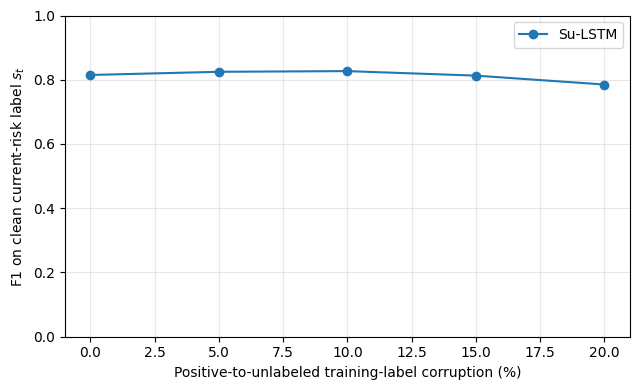

In [12]:
if not results.empty:
    plot_df = results.sort_values("noise_rate")

    plt.figure(figsize=(6.5, 4.0))
    plt.plot(
        100 * plot_df["noise_rate"],
        plot_df["f1"],
        marker="o",
        label="Su-LSTM",
    )
    plt.xlabel("Positive-to-unlabeled training-label corruption (%)")
    plt.ylabel("F1 on clean current-risk label $s_t$")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Important reporting rule

For the current paper comparison, use the `f1` column because it is evaluated on the same clean endpoint-level current-risk target `s_t` as the matched TF/GAT/CMPA experiments.

The `outcome_f1` column reflects the older fully supervised scenario-outcome task. It is provided only as a diagnostic and should **not** be plotted together with current-risk F1.

If the newly measured Su-LSTM curve differs from historical values imported from the older LSTM paper, the manuscript should be updated to the results from this matched experiment.
